In [26]:
import sys
!{sys.executable} -m pip install cfgrib eccodes
!{sys.executable} -m pip install windrose

In [18]:
import xarray as xr
print(xr.backends.list_engines())

{'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'cfgrib': <CfGribBackend>
  Open GRIB files (.grib, .grib2, .grb and .grb2) in Xarray
  Learn more at https://github.com/ecmwf/cfgrib, 'gini': <GiniXarrayBackend>, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}


In [19]:
import cfgrib
import os

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

files = [f for f in os.listdir(data_dir) if f.endswith('.grib')]
print(f"Total GRIB files: {len(files)}")
print()

for f in files:
    full_path = os.path.join(data_dir, f)
    datasets = cfgrib.open_datasets(full_path)
    for i, ds in enumerate(datasets):
        print(f"{f[:20]}...")
        print(f"  Variables: {list(ds.data_vars)}")
        print(f"  Time: {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]}")
        print(f"  Length: {len(ds.time.values)}")
    print()

Total GRIB files: 4

4442e4d799f439dfe045...
  Variables: ['u100', 'v100']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144

5996358addf110711f83...
  Variables: ['mwd']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144

87651c937f5a950f80d1...
  Variables: ['swh', 'pp1d']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144

98aa70fc79993ea5c3b6...
  Variables: ['u10', 'v10']
  Time: 2010-01-01 to 2020-12-31
  Length: 32144



In [20]:
import cfgrib
import numpy as np

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

site_lat = 37.74838
site_lon = -9.01453

#File names
file_10m  = '98aa70fc79993ea5c3b6c54879df5625.grib' 
file_100m = '4442e4d799f439dfe0452da8fb8de243.grib'
file_wave = '87651c937f5a950f80d1c4291b8e5ed5.grib'

#Load datasets 
ds_10m  = cfgrib.open_datasets(data_dir + '\\' + file_10m)[0]
ds_100m = cfgrib.open_datasets(data_dir + '\\' + file_100m)[0]
ds_wave = cfgrib.open_datasets(data_dir + '\\' + file_wave)[0]

# Nearest point to Sines 
pt_10m  = ds_10m.sel(latitude=site_lat,  longitude=site_lon, method='nearest')
pt_100m = ds_100m.sel(latitude=site_lat, longitude=site_lon, method='nearest')
pt_wave = ds_wave.sel(latitude=site_lat, longitude=site_lon, method='nearest')

print(f"pt_10m:  {len(pt_10m.time.values)} records")
print(f"pt_100m: {len(pt_100m.time.values)} records")
print(f"pt_wave: {len(pt_wave.time.values)} records")

pt_10m:  32144 records
pt_100m: 32144 records
pt_wave: 32144 records


In [21]:
# Check time steps
import numpy as np

times_10m  = pt_10m.time.values
times_100m = pt_100m.time.values
times_wave = pt_wave.time.values

# Check interval between first few timestamps
dt_10m  = (times_10m[1]  - times_10m[0])  / np.timedelta64(1, 'h')
dt_100m = (times_100m[1] - times_100m[0]) / np.timedelta64(1, 'h')
dt_wave = (times_wave[1] - times_wave[0]) / np.timedelta64(1, 'h')

print(f"10m  time step: {dt_10m} hours")
print(f"100m time step: {dt_100m} hours")
print(f"wave time step: {dt_wave} hours")

10m  time step: 3.0 hours
100m time step: 3.0 hours
wave time step: 3.0 hours


In [22]:
import pandas as pd
import numpy as np
import os

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

# ── Wind DataFrame (all in one since timestamps match) ────────────
df_wind = pd.DataFrame({
    'wind_speed_10m_ms':  np.sqrt(pt_10m['u10'].values**2 + pt_10m['v10'].values**2),
    'wind_dir_10m_deg':   (270 - np.degrees(np.arctan2(pt_10m['v10'].values, pt_10m['u10'].values))) % 360,
    'wind_speed_100m_ms': np.sqrt(pt_100m['u100'].values**2 + pt_100m['v100'].values**2),
    'wind_dir_100m_deg':  (270 - np.degrees(np.arctan2(pt_100m['v100'].values, pt_100m['u100'].values))) % 360,
}, index=pd.DatetimeIndex(pt_100m.time.values))

# ── Wave DataFrame ────────────────────────────────────────────────
df_wave = pd.DataFrame({
    'Hs_m': pt_wave['swh'].values,
    'Tp_s': pt_wave['pp1d'].values,
}, index=pd.DatetimeIndex(pt_wave.time.values))

print(f"Wind records:   {len(df_wind)}")
print(f"Wave records:   {len(df_wave)}")
print(f"Missing values (wind): {df_wind.isna().sum().sum()}")
print(f"Missing values (wave): {df_wave.isna().sum().sum()}")

# ── Save CSVs ─────────────────────────────────────────────────────
df_wind.to_csv(os.path.join(data_dir, 'wind_data_sines_2010_2020.csv'))
df_wave.to_csv(os.path.join(data_dir, 'wave_data_sines_2010_2020.csv'))

print("\nWind sample:")
print(df_wind.head())
print("\nWave sample:")
print(df_wave.head())
print("\nCSVs saved!")

Wind records:   32144
Wave records:   32144
Missing values (wind): 0
Missing values (wave): 0

Wind sample:
                     wind_speed_10m_ms  wind_dir_10m_deg  wind_speed_100m_ms  \
2010-01-01 00:00:00          11.378973        274.830200           13.204857   
2010-01-01 03:00:00          12.063279        277.673767           14.090853   
2010-01-01 06:00:00          12.025712        283.169434           14.135208   
2010-01-01 09:00:00          11.216561        287.584412           13.078920   
2010-01-01 12:00:00           9.727643        286.973114           11.236833   

                     wind_dir_100m_deg  
2010-01-01 00:00:00         274.922241  
2010-01-01 03:00:00         277.744537  
2010-01-01 06:00:00         282.981934  
2010-01-01 09:00:00         287.573883  
2010-01-01 12:00:00         287.262848  

Wave sample:
                         Hs_m       Tp_s
2010-01-01 00:00:00  4.356820  11.297707
2010-01-01 03:00:00  4.161001  11.206398
2010-01-01 06:00:00  4.12316

In [23]:
import pandas as pd
import cfgrib
import os

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

site_lat = 37.74838

# Load wave direction file
wave_dir_file = os.path.join(data_dir, '5996358addf110711f83f302d0f8b1.grib')
ds_wavedir = cfgrib.open_datasets(wave_dir_file)[0]

# Only select latitude (longitude is already a single point at -9.0)
pt_wavedir = ds_wavedir.sel(latitude=site_lat, method='nearest')

print(f"Extracted at latitude: {float(pt_wavedir.latitude.values):.4f}")
print(f"Longitude: {float(ds_wavedir.longitude.values):.4f}")
print(f"Records: {len(pt_wavedir.time.values)}")
print(pt_wavedir['mwd'].values[:5])

# Build and save separate CSV
df_wavedir = pd.DataFrame({
    'wave_dir_deg': pt_wavedir['mwd'].values,
}, index=pd.DatetimeIndex(pt_wavedir.time.values))

wave_dir_csv = os.path.join(data_dir, 'wave_direction_sines_2010_2020.csv')
df_wavedir.to_csv(wave_dir_csv)

print(f"\nSample:")
print(df_wavedir.head())
print(f"\nWave direction CSV saved! ({len(df_wavedir)} records)")

Extracted at latitude: 37.5000
Longitude: -9.0000
Records: 32144
[286.52393 288.67395 290.76672 294.81274 301.3291 ]

Sample:
                     wave_dir_deg
2010-01-01 00:00:00    286.523926
2010-01-01 03:00:00    288.673950
2010-01-01 06:00:00    290.766724
2010-01-01 09:00:00    294.812744
2010-01-01 12:00:00    301.329102

Wave direction CSV saved! (32144 records)


In [24]:
import pandas as pd
import numpy as np

data_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'

df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)
df_wave = pd.read_csv(data_dir + r'\wave_data_sines_2010_2020.csv', index_col=0, parse_dates=True)
df_wavedir = pd.read_csv(data_dir + r'\wave_direction_sines_2010_2020.csv', index_col=0, parse_dates=True)

print("=== WIND AT 10m ===")
print(f"Mean speed:      {df_wind['wind_speed_10m_ms'].mean():.2f} m/s")
print(f"Std speed:       {df_wind['wind_speed_10m_ms'].std():.2f} m/s")
print(f"Min speed:       {df_wind['wind_speed_10m_ms'].min():.2f} m/s")
print(f"Max speed:       {df_wind['wind_speed_10m_ms'].max():.2f} m/s")

print("\n=== WIND AT 100m ===")
print(f"Mean speed:      {df_wind['wind_speed_100m_ms'].mean():.2f} m/s")
print(f"Std speed:       {df_wind['wind_speed_100m_ms'].std():.2f} m/s")
print(f"Min speed:       {df_wind['wind_speed_100m_ms'].min():.2f} m/s")
print(f"Max speed:       {df_wind['wind_speed_100m_ms'].max():.2f} m/s")

print("\n=== WAVE HEIGHT (Hs) ===")
print(f"Mean Hs:         {df_wave['Hs_m'].mean():.2f} m")
print(f"Std Hs:          {df_wave['Hs_m'].std():.2f} m")
print(f"Min Hs:          {df_wave['Hs_m'].min():.2f} m")
print(f"Max Hs:          {df_wave['Hs_m'].max():.2f} m")

print("\n=== WAVE PERIOD (Tp) ===")
print(f"Mean Tp:         {df_wave['Tp_s'].mean():.2f} s")
print(f"Std Tp:          {df_wave['Tp_s'].std():.2f} s")
print(f"Min Tp:          {df_wave['Tp_s'].min():.2f} s")
print(f"Max Tp:          {df_wave['Tp_s'].max():.2f} s")

print("\n=== WAVE DIRECTION (mwd) ===")
print(f"Mean direction:  {df_wavedir['wave_dir_deg'].mean():.1f} °")
print(f"Std direction:   {df_wavedir['wave_dir_deg'].std():.1f} °")
print(f"Min direction:   {df_wavedir['wave_dir_deg'].min():.1f} °")
print(f"Max direction:   {df_wavedir['wave_dir_deg'].max():.1f} °")

# Dominant direction sector for both wind and waves
bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

df_wind['wind_sector'] = pd.cut(df_wind['wind_dir_10m_deg'], bins=bins, labels=labels)
df_wavedir['wave_sector'] = pd.cut(df_wavedir['wave_dir_deg'], bins=bins, labels=labels)

print(f"\nDominant wind direction:  {df_wind['wind_sector'].value_counts().idxmax()}")
print(f"Dominant wave direction:  {df_wavedir['wave_sector'].value_counts().idxmax()}")

print("\n=== WIND DIRECTION BREAKDOWN ===")
print(df_wind['wind_sector'].value_counts().sort_index())

print("\n=== WAVE DIRECTION BREAKDOWN ===")
print(df_wavedir['wave_sector'].value_counts().sort_index())

=== WIND AT 10m ===
Mean speed:      5.87 m/s
Std speed:       2.70 m/s
Min speed:       0.02 m/s
Max speed:       18.54 m/s

=== WIND AT 100m ===
Mean speed:      7.29 m/s
Std speed:       3.46 m/s
Min speed:       0.01 m/s
Max speed:       23.39 m/s

=== WAVE HEIGHT (Hs) ===
Mean Hs:         1.96 m
Std Hs:          0.90 m
Min Hs:          0.47 m
Max Hs:          7.75 m

=== WAVE PERIOD (Tp) ===
Mean Tp:         11.20 s
Std Tp:          2.70 s
Min Tp:          3.23 s
Max Tp:          21.39 s

=== WAVE DIRECTION (mwd) ===
Mean direction:  306.4 °
Std direction:   30.6 °
Min direction:   0.1 °
Max direction:   360.0 °

Dominant wind direction:  NW
Dominant wave direction:  W

=== WIND DIRECTION BREAKDOWN ===
wind_sector
N      5067
NE     2216
E      1323
SE     1576
S      2500
SW     2570
W      4411
NW    12481
Name: count, dtype: int64

=== WAVE DIRECTION BREAKDOWN ===
wave_sector
N        91
NE       47
E        93
SE       92
S       174
SW     1590
W     15655
NW    14402
Name: c

C:\Users\Carolina\AppData\Local\Temp\ipykernel_16336\3567076419.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


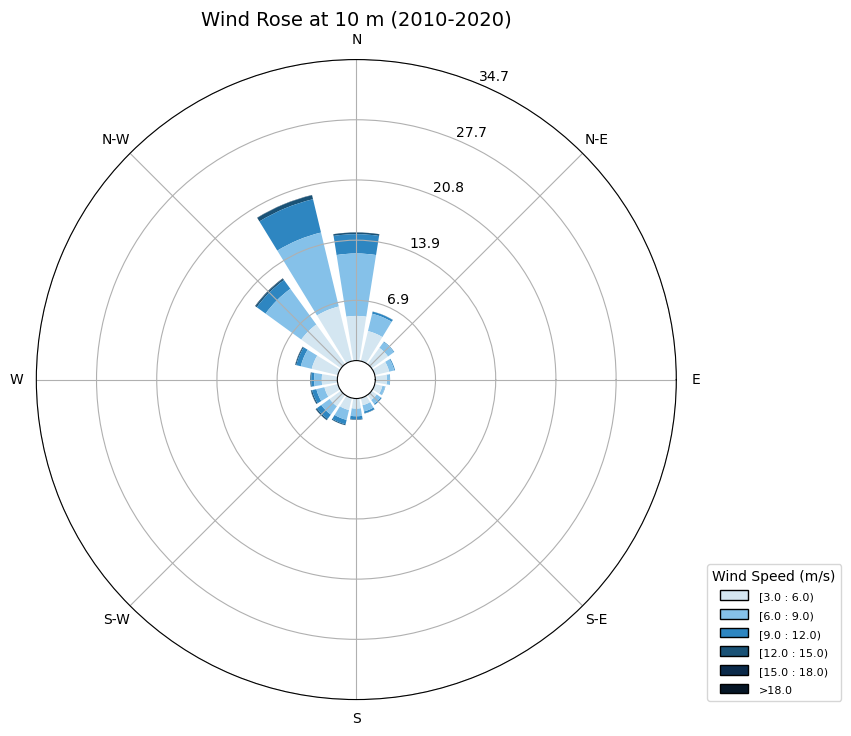

In [32]:
import matplotlib.pyplot as plt
from windrose import WindroseAxes

data_fig_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data\figures'

df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(df_wind['wind_dir_10m_deg'], 
       df_wind['wind_speed_10m_ms'], 
       normed=True, 
       bins=[3,6,9,12,15,18],
       calm_limit=3,
        colors=['#d4e6f1','#85c1e9','#2e86c1','#1a5276','#0b2a4a','#061626'],
       nsector=16,       linewidth=0.5)

ax.set_legend(title='Wind Speed (m/s)', 
              loc='lower left', 
              bbox_to_anchor=(1.05, 0),
              fontsize=10)
ax.set_title('Wind Rose at 10 m (2010-2020)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'wind_rose_10m.png'), dpi=300, bbox_inches='tight')
plt.show()


predoinant in NNW 
secondary sector from NNE
light contributions spread across other directions


C:\Users\Carolina\AppData\Local\Temp\ipykernel_16336\1499857463.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


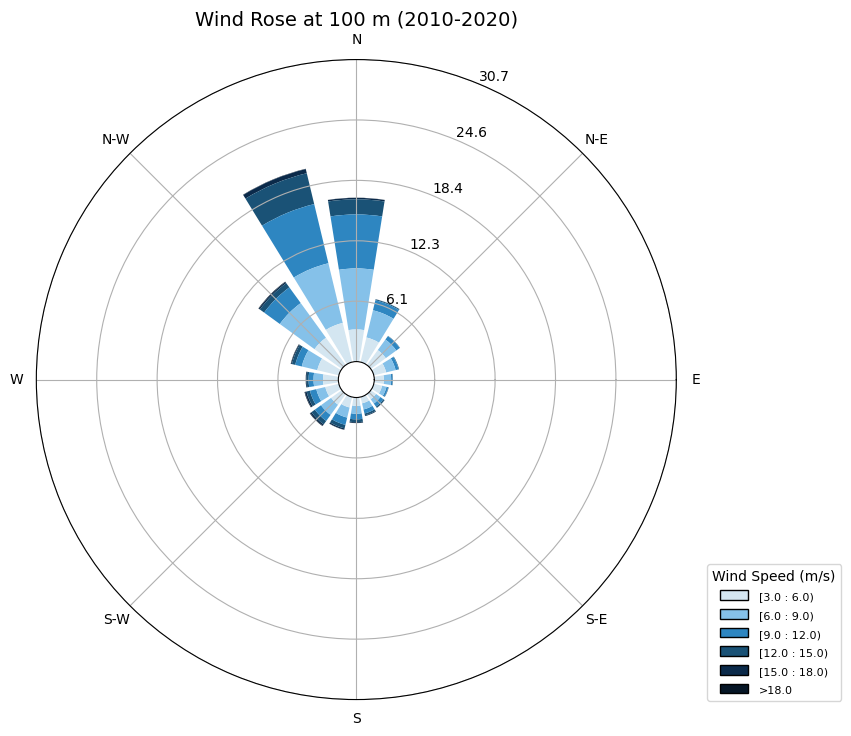

In [37]:
data_fig_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data\figures'

df_wind = pd.read_csv(data_dir + r'\wind_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)

ax.bar(df_wind['wind_dir_100m_deg'], 
       df_wind['wind_speed_100m_ms'], 
       normed=True, 
       bins=[3,6,9,12,15,18],
       calm_limit=3,
        colors=['#d4e6f1','#85c1e9','#2e86c1','#1a5276','#0b2a4a','#061626'],
       nsector=16,       linewidth=0.5)

ax.set_legend(title='Wind Speed (m/s)', 
              loc='lower left', 
              bbox_to_anchor=(1.05, 0),
              fontsize=10)
ax.set_title('Wind Rose at 100 m (2010-2020)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'wind_rose_100m.png'), dpi=300, bbox_inches='tight')
plt.show()


reaches speeds larger than 15m/s  
more concentrated around N  


In [36]:
#m/s to km/h
v3= 3*3.6
print(f"3 m/s = {v3:.1f} km/h")
v6= 6*3.6
print(f"6 m/s = {v6:.1f} km/h")
v9= 9*3.6
print(f"9 m/s = {v9:.1f} km/h")
v12= 12*3.6
print(f"12 m/s = {v12:.1f} km/h")
v15= 15*3.6    
print(f"15 m/s = {v15:.1f} km/h")
v18= 18*3.6
print(f"18 m/s = {v18:.1f} km/h")

3 m/s = 10.8 km/h
6 m/s = 21.6 km/h
9 m/s = 32.4 km/h
12 m/s = 43.2 km/h
15 m/s = 54.0 km/h
18 m/s = 64.8 km/h


                         Hs_m       Tp_s
2010-01-01 00:00:00  4.356820  11.297707
2010-01-01 03:00:00  4.161001  11.206398
2010-01-01 06:00:00  4.123161  11.046730
2010-01-01 09:00:00  4.093586  11.074074
2010-01-01 12:00:00  4.266944  11.590187

Total records: 32144
Time range: 2010-01-01 00:00:00 to 2020-12-31 21:00:00


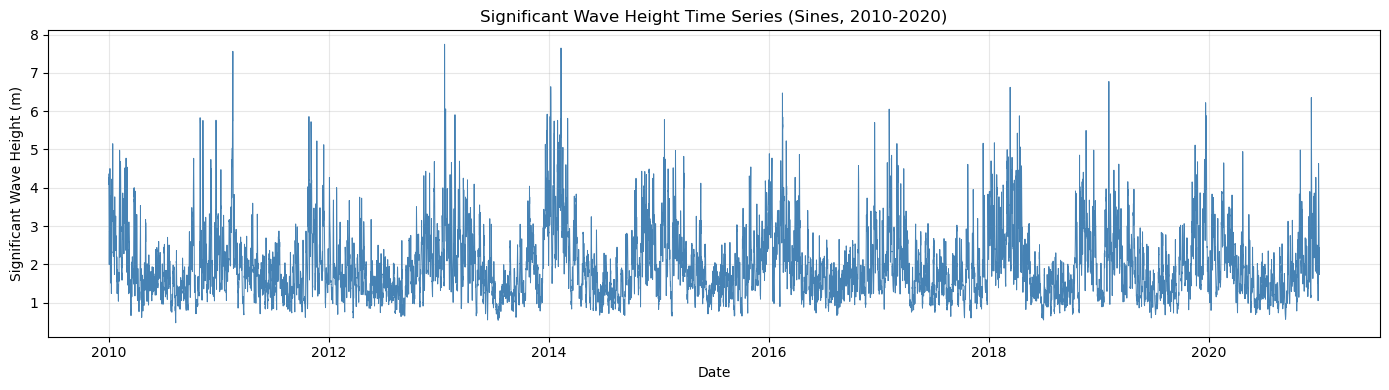

In [33]:
#time series Hs

#load wave data


df_wave = pd.read_csv(data_dir + r'\wave_data_sines_2010_2020.csv', index_col=0, parse_dates=True)

print(df_wave.head())
print(f"\nTotal records: {len(df_wave)}")
print(f"Time range: {df_wave.index[0]} to {df_wave.index[-1]}")

plt.figure(figsize=(14, 4))
plt.plot(df_wave.index, df_wave['Hs_m'], color='steelblue', linewidth=0.7) 
plt.xlabel('Date')
plt.ylabel('Significant Wave Height (m)')
plt.title('Significant Wave Height Time Series (Sines, 2010-2020)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'hs_timeseries.png'), dpi=300, bbox_inches='tight')
plt.show()


C:\Users\Carolina\AppData\Local\Temp\ipykernel_16336\2844862074.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


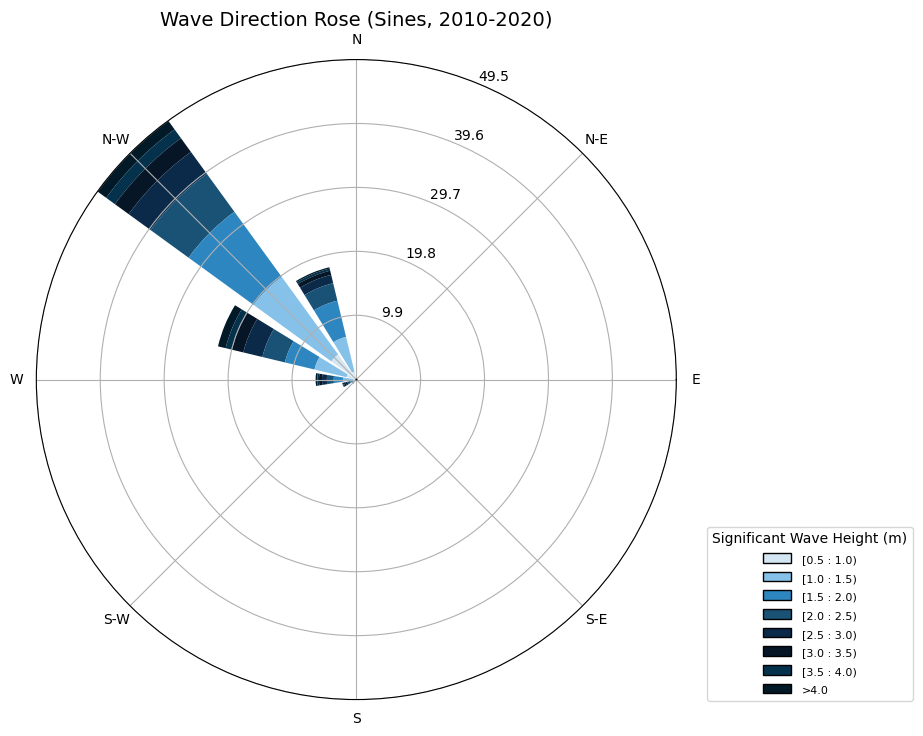

In [35]:
# wave direction rose

df_wavedir = pd.read_csv(data_dir + r'\wave_direction_sines_2010_2020.csv', index_col=0, parse_dates=True)

df_combined = df_wave.join(df_wavedir, how='inner')

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(df_combined['wave_dir_deg'], 
       df_combined['Hs_m'], 
       normed=True, 
       bins=[0.5,1,1.5,2,2.5,3,3.5,4],
       calm_limit=0.5,
       colors=['#d4e6f1','#85c1e9','#2e86c1','#1a5276','#0b2a4a','#061626','#04314c','#021927'],
       nsector=16, linewidth=0.5)
ax.set_legend(title='Significant Wave Height (m)', 
              loc='lower left', 
              bbox_to_anchor=(1.05, 0),
              fontsize=10)
ax.set_title('Wave Direction Rose (Sines, 2010-2020)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(data_fig_dir, 'wave_direction_rose.png'), dpi=300, bbox_inches='tight')
plt.show()

note that in Sines city, the wave direction is difrent. however, the site is more to the south and west, therefore it is different!!   
if we google sines: for the best surfing conditions in Sines, Portugal, the ideal swell (wave) direction is West to Southwest  
if we google porto corvo (the closest city if we draw a horizontal line): The typical and ideal wave (swell) direction in Porto Covo, Portugal is Northwest (NW)


atlantic swell coming  from the northwest  
largest waves in NW sector   
